FIRST 5 ROWS OF DATASET
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.

/tmp/ipykernel_3753/3613687577.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_3753/3613687577.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

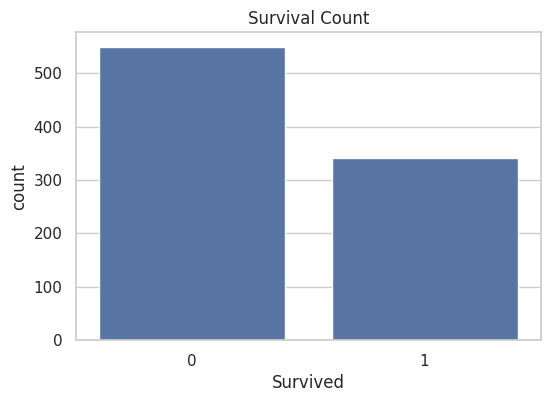

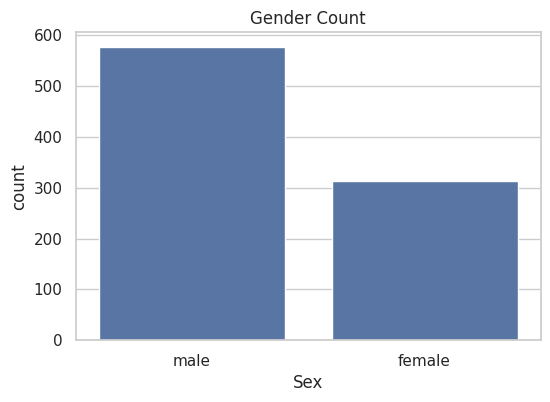

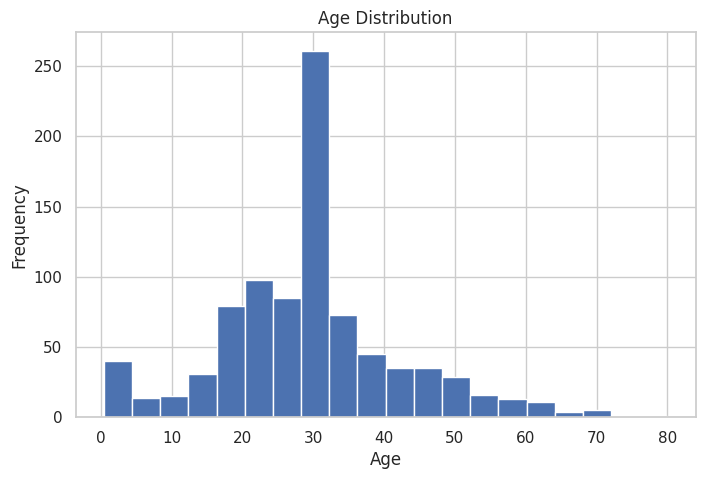

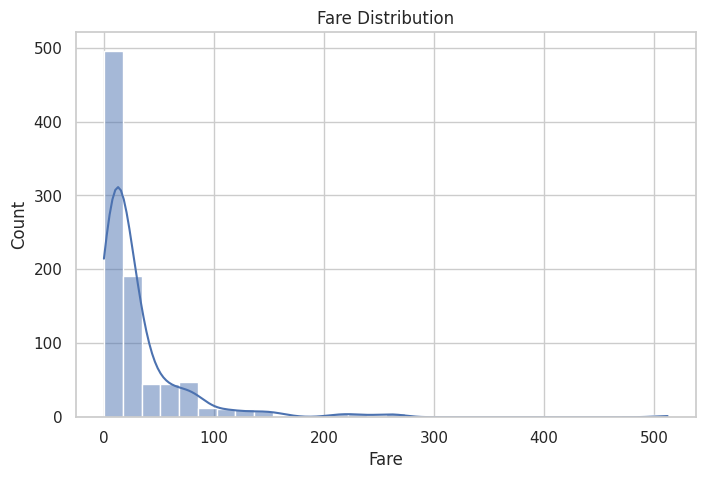

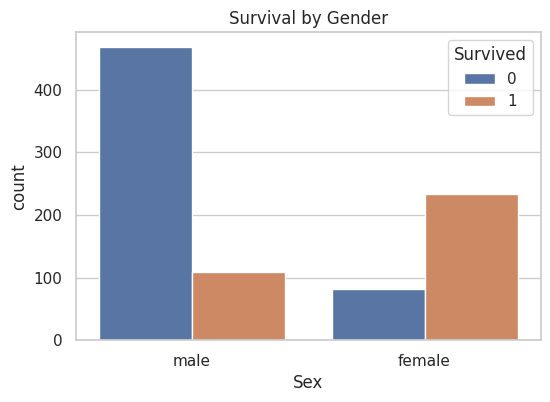

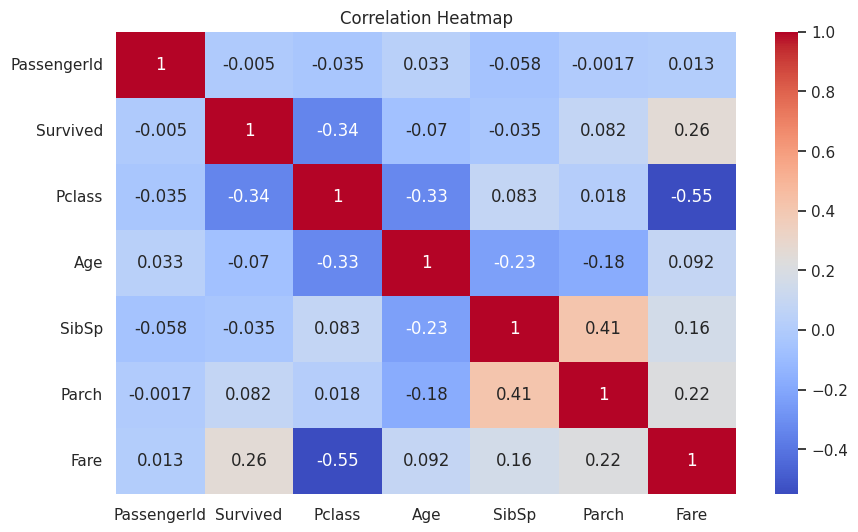

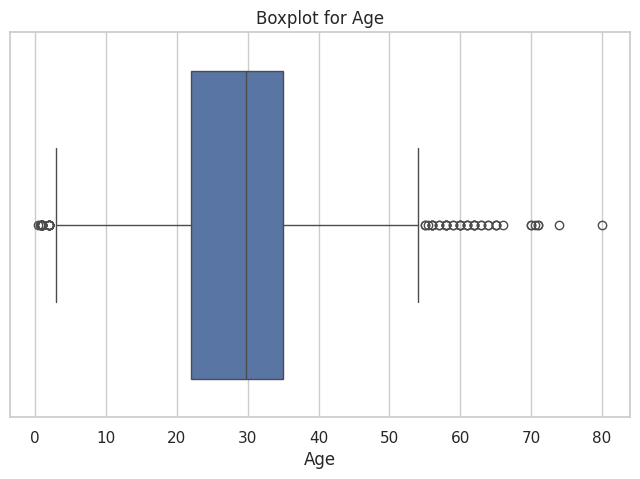


CLEANED DATASET SAVED SUCCESSFULLY!

PROJECT INSIGHTS:
1. Most passengers were male.
2. Female passengers had higher survival rates.
3. Most passengers were between 20-40 years old.
4. Fare values contain some outliers.
5. Data cleaning improved dataset quality.


In [2]:
# ============================================
# DATA CLEANING & VISUALIZATION PROJECT
# Titanic Dataset Analysis
# ============================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------
# STEP 1: LOAD DATASET
# --------------------------------------------

df = pd.read_csv("titanic.csv")

print("FIRST 5 ROWS OF DATASET")
print(df.head())

# --------------------------------------------
# STEP 2: BASIC INFORMATION
# --------------------------------------------

print("\nDATASET INFORMATION")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nSTATISTICAL SUMMARY")
print(df.describe())

# --------------------------------------------
# STEP 3: DATA CLEANING
# --------------------------------------------

df.drop_duplicates(inplace=True)

df['Age'].fillna(df['Age'].mean(), inplace=True)

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df['Fare'].fillna(df['Fare'].mean(), inplace=True)

df.drop(columns=['Cabin'], inplace=True)

print("\nMISSING VALUES AFTER CLEANING")
print(df.isnull().sum())

# --------------------------------------------
# STEP 4: VISUALIZATION
# --------------------------------------------

sns.set(style="whitegrid")

# Survival Count
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

# Gender Count
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=df)
plt.title("Gender Count")
plt.show()

# Age Distribution
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Fare Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

# Survival by Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

# Heatmap
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Age'])
plt.title("Boxplot for Age")
plt.show()

# --------------------------------------------
# STEP 5: SAVE CLEANED DATA
# --------------------------------------------

df.to_csv("cleaned_titanic.csv", index=False)

print("\nCLEANED DATASET SAVED SUCCESSFULLY!")

# --------------------------------------------
# STEP 6: INSIGHTS
# --------------------------------------------

print("\nPROJECT INSIGHTS:")
print("1. Most passengers were male.")
print("2. Female passengers had higher survival rates.")
print("3. Most passengers were between 20-40 years old.")
print("4. Fare values contain some outliers.")
print("5. Data cleaning improved dataset quality.")